# Example 3: fifth-order double-quantum spectroscopy of two coupled anharmonic modes

Two coupled bosonic modes with anharmonic interactions are a minimal model of a chromophore with a high- and a low-energy vibration or exciton. Its fifth-order double-quantum (2Q) spectrum has many pathways, which UFSS enumerates for us. In this notebook you will:

- build the two-mode model with QuTiP bosonic operators and truncate it to at most three excitations;
- generate the seven fifth-order pathways automatically with UFSS;
- compute a 2Q map with the `generate_nq_spectrum` interface;
- assign its strongest feature to eigenenergies of the model;
- split the detected polarization into the contribution of each mode.

Convergence with the excitation cutoff, higher resolution, pathway completeness and the harmonic-limit cancellation are in `analysis/example3_truncation_and_validation.ipynb`.

Natural units: $\hbar=1$, energies in eV, times in eV$^{-1}$.

## 0. Imports

The matrices here are tiny (Liouville dimension 100), so multithreaded BLAS only adds synchronization cost. The first cell restricts it to one thread; the variables are read when NumPy is imported, so they must be set before.

In [1]:
import os

for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(variable, "1")

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
import ufss

from qudpy_fdgf import (
    EigenbasisKModel,
    SpectroscopySolver,
    standard_nq_protocol,
    translate_ufss_diagrams,
)

## 1. Physical model

Two bosonic modes $h$ (high) and $l$ (low) with annihilation operators $b_h,b_l$ and number operators $n_i=b_i^\dagger b_i$:

$$
H=\omega_hn_h+\omega_ln_l+V\big(b_h^\dagger b_l+b_l^\dagger b_h\big)
+\tfrac12U_{hh}\,n_h(n_h-1)+\tfrac12U_{ll}\,n_l(n_l-1)+U_{hl}\,n_hn_l .
$$

$V$ couples the modes, and the $U$ terms are anharmonicities. The light couples through the dipole

$$
\mu=\mu_h(b_h+b_h^\dagger)+\mu_l(b_l+b_l^\dagger)=J_++J_-,\qquad J_+=\mu_hb_h^\dagger+\mu_lb_l^\dagger .
$$

$H$ conserves the total excitation number $n_h+n_l$, so the Hilbert space splits into manifolds (0, 1, 2, 3, … excitations). The solver is told which operator raises ($J_+$) and lowers ($J_-$) the manifold.

In [2]:
omega_h, omega_l = 1.53, 1.58      # mode energies (eV)
coupling = 0.010                   # V
U_hh, U_ll, U_hl = -0.020, -0.020, 0.030
mu_h, mu_l = 1.0, 0.30

cutoff = 4                         # Fock levels per mode before truncation
b_h = qt.tensor(qt.destroy(cutoff), qt.qeye(cutoff))
b_l = qt.tensor(qt.qeye(cutoff), qt.destroy(cutoff))
n_h, n_l = b_h.dag() * b_h, b_l.dag() * b_l
identity = qt.qeye([cutoff, cutoff])

H_full = (
    omega_h * n_h + omega_l * n_l
    + coupling * (b_h.dag() * b_l + b_l.dag() * b_h)
    + 0.5 * U_hh * n_h * (n_h - identity) + 0.5 * U_ll * n_l * (n_l - identity)
    + U_hl * n_h * n_l
)
J_plus_full = mu_h * b_h.dag() + mu_l * b_l.dag()
polarization_h_full = mu_h * (b_h + b_h.dag())
polarization_l_full = mu_l * (b_l + b_l.dag())

### Truncation to at most three excitations

Two excitations are enough for the 2Q interval itself, but a complete fifth-order pathway can reach three excitations before detection (the final $|3\rangle\langle2|$ coherence). We therefore keep $n_h+n_l\le N_{\max}=3$, which leaves 10 states, ordered by manifold. Since $H$ conserves $n_h+n_l$, cutting the space this way does not change the energies of the retained manifolds.

In [3]:
max_manifold = 3

# Fock states (n_h, n_l) of the tensor basis, kept if their total is <= max_manifold,
# then ordered by manifold (and by decreasing n_h inside a manifold).
states = [(nh, nl) for nh in range(cutoff) for nl in range(cutoff) if nh + nl <= max_manifold]
states.sort(key=lambda s: (sum(s), -s[0]))
keep = [nh * cutoff + nl for nh, nl in states]


def truncate(operator):
    """Restrict a Qobj of the full tensor space to the retained states."""
    return qt.Qobj(operator.full()[np.ix_(keep, keep)])


H_site = truncate(H_full)
J_plus = truncate(J_plus_full)
J_minus = J_plus.dag()
mu = J_plus + J_minus

print("basis (n_h, n_l):", states)

basis (n_h, n_l): [(0, 0), (1, 0), (0, 1), (2, 0), (1, 1), (0, 2), (3, 0), (2, 1), (1, 2), (0, 3)]


## 2. Model and solver

`EigenbasisKModel` receives $H$, the transition operator $\mu$, the manifold-changing operators $J_\pm$ and the detection operator. The extra observables `polarization_h` and `polarization_l` are the contributions of each mode to the detected polarization (Section 5). The model is closed (no collapse channels): the only damping is the resolvent broadening $\eta$.

The default dense resolvent cache holds 32 entries, far fewer than the working set of a $151\times151$ scan, so `max_cache_entries` is raised.

In [4]:
model = EigenbasisKModel(
    H_site,
    mu,
    j_plus_array=J_plus,
    j_minus_array=J_minus,
    detection_op_array=mu,
    observable_op_arrays={
        "polarization": mu,
        "polarization_h": truncate(polarization_h_full),
        "polarization_l": truncate(polarization_l_full),
    },
)

eta = 0.008        # eV, resolvent broadening (8 meV)
solver = SpectroscopySolver(backend="dense", eta=eta, max_cache_entries=4096)
solver.feed_model(model)

# Eigenenergies per manifold (ascending order separates the manifolds here)
energies = H_site.eigenenergies()
epsilon, E_two, E_three = energies[1:3], energies[3:6], energies[6:10]
print("one-excitation energies:   ", np.round(epsilon, 4))
print("two-excitation energies:   ", np.round(E_two, 4))
print("three-excitation energies: ", np.round(E_three, 4))

one-excitation energies:    [1.5281 1.5819]
two-excitation energies:    [3.038 3.127 3.155]
three-excitation energies:  [4.528  4.6695 4.6809 4.7415]


## 3. Pathways generated by UFSS

The fifth-order 2Q signal has five interactions. UFSS needs the phase-discrimination pattern, one `(bra, ket)` count per pulse: the first two pulses act on the ket and the last three on the bra, so the signal carries the coherence orders $q=(-1,-2,-1,0,+1)$, with $q=-2$ the double-quantum coherence. `maximum_manifold` stops the ladder at three excitations, matching the truncation.

`translate_ufss_diagrams` converts the diagrams to `FrequencyPathway` objects of the component `"chi5_2q"`.

In [5]:
diagram_generator = ufss.DiagramGenerator(detection_type="polarization")
diagram_generator.set_phase_discrimination([(0, 1), (0, 1), (1, 0), (1, 0), (1, 0)])
diagram_generator.maximum_manifold = max_manifold
diagram_generator.efield_times = [np.array([0.0, 0.0])] * 5
diagrams = diagram_generator.get_diagrams(np.arange(5, dtype=float))

pathways = translate_ufss_diagrams(diagrams, component="chi5_2q")
solver.set_pathways(pathways)

print(f"{len(pathways)} pathways")
for pathway in pathways:
    labels = " ".join(i.label for i in pathway.interactions)
    print(f"  {pathway.name}: {labels}   q = {pathway.coherence_orders}")

7 pathways
  P1: Bu Bu Ku Ku Ku   q = (-1, -2, -1, 0, 1)
  P2: Bu Bu Ku Ku Bd   q = (-1, -2, -1, 0, 1)
  P3: Bu Bu Ku Bd Ku   q = (-1, -2, -1, 0, 1)
  P4: Bu Bu Ku Bd Bd   q = (-1, -2, -1, 0, 1)
  P5: Bu Bu Bd Ku Ku   q = (-1, -2, -1, 0, 1)
  P6: Bu Bu Bd Ku Bd   q = (-1, -2, -1, 0, 1)
  P7: Bu Bu Bd Bd Ku   q = (-1, -2, -1, 0, 1)


Seven pathways survive. The first two interactions are always $B_uB_u$ (the double-quantum coherence), and the last three are the seven orderings of $K_u$ and $B_d$ steps that do not leave the ladder.

## 4. Protocol and 2Q spectrum

`standard_nq_protocol(order=2, ...)` declares:

- `nq_interval=2`: the second interval ($q=-2$) is the double-quantum coherence, transformed to `omega_2q`;
- `detection_interval=5`: the fifth interval is the emitted coherence, transformed to `omega_emit`;
- the other intervals $t_1,t_3,t_4$ stay in the time domain and are held fixed.

`generate_nq_spectrum(2, ...)` evaluates the pathways and groups the result by coherence order (`-2Q` and `+2Q`). The extra `observables` are computed from the same propagated states. The 2Q signal lives in `components["chi5_2q"]`; `"+2Q"` is empty for this phase signature.

In [6]:
protocol = standard_nq_protocol(
    order=2, nq_interval=2, detection_interval=5, n_interactions=5,
    nq_axis="omega_2q", detection_axis="omega_emit",
)
fixed_delays = {"t1": 2.0, "t3": 2.0, "t4": 2.0}

omega_2q = np.linspace(-3.20, -2.99, 151)
omega_emit = np.linspace(1.42, 1.66, 151)

result = solver.generate_nq_spectrum(
    2,
    protocol,
    axes={"omega_2q": omega_2q, "omega_emit": omega_emit},
    fixed_coordinates=fixed_delays,
    pathways=pathways,
    observables=("polarization_h", "polarization_l"),
)
spectrum = result.components["chi5_2q"]
print("array shape (omega_2q, omega_emit):", spectrum.shape)

array shape (omega_2q, omega_emit): (151, 151)


### The map

White lines mark $-E_k$ for the three two-excitation states $E_k$ (the 2Q frequency is negative for this convention).

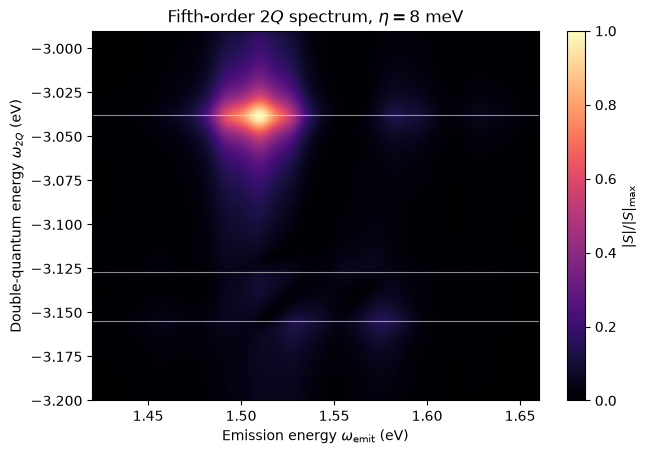

In [7]:
magnitude = np.abs(spectrum)
map_figure, ax = plt.subplots(figsize=(7.2, 4.8))
image = ax.imshow(
    magnitude / magnitude.max(),
    origin="lower", aspect="auto", cmap="magma", vmin=0.0, vmax=1.0,
    extent=(omega_emit[0], omega_emit[-1], omega_2q[0], omega_2q[-1]),
)
for energy in E_two:
    ax.axhline(-energy, color="white", lw=0.8, alpha=0.55)
ax.set_xlabel(r"Emission energy $\omega_{\mathrm{emit}}$ (eV)")
ax.set_ylabel(r"Double-quantum energy $\omega_{2Q}$ (eV)")
ax.set_title(r"Fifth-order $2Q$ spectrum, $\eta=8$ meV")
map_figure.colorbar(image, ax=ax, label=r"$|S|/|S|_{\max}$")
plt.show()

### Assignment of the strongest feature

The strongest feature is expected at

$$(\omega_{2Q},\omega_{\rm emit})=(-E_1,\;E_1-\varepsilon_1),$$

where $E_1$ is the lowest two-excitation energy and $\varepsilon_1$ the lowest one-excitation energy. The vertical coordinate selects a two-excitation state; the emission frequency is that of a $|2\rangle\langle1|$ coherence. At $\eta=8$ meV neighbouring poles overlap and their complex amplitudes interfere, so the peak is *consistent with* this assignment, not an independent measurement of the eigenenergies.

In [8]:
i, j = np.unravel_index(np.argmax(magnitude), magnitude.shape)
print(f"strongest feature: ({omega_2q[i]:.3f}, {omega_emit[j]:.3f}) eV")
print(f"expected (-E_1, E_1 - eps_1) = ({-E_two[0]:.3f}, {E_two[0] - epsilon[0]:.3f}) eV")
print(f"peak amplitude |S|_max = {magnitude.max():.3e}")

grid_step = max(omega_2q[1] - omega_2q[0], omega_emit[1] - omega_emit[0])
assert abs(omega_2q[i] + E_two[0]) < 3 * grid_step
assert abs(omega_emit[j] - (E_two[0] - epsilon[0])) < 3 * grid_step

strongest feature: (-3.038, 1.510) eV
expected (-E_1, E_1 - eps_1) = (-3.038, 1.510) eV
peak amplitude |S|_max = 1.256e+05


## 5. Mode-resolved detection

The two extra observables replace the transition operator at detection by the dipole of one mode, $\mu_h(b_h+b_h^\dagger)$ or $\mu_l(b_l+b_l^\dagger)$. Because $\mu=\mu_h(\dots)+\mu_l(\dots)$, the polarizations add up exactly. This confirms that extra observables reuse the same propagated state, and it is a decomposition of the detected amplitude, not a population of the two-excitation eigenstate.

We look at the cut through the strongest feature, $\omega_{2Q}=-E_1$.

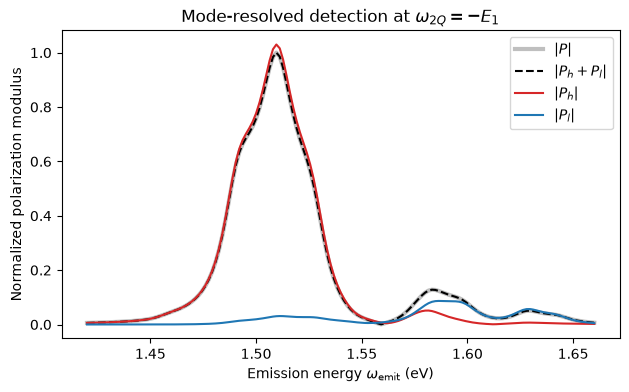

relative residual |P - (P_h + P_l)| / |P|max = 3.5e-16


In [9]:
row = int(np.argmin(np.abs(omega_2q + E_two[0])))
total = spectrum[row]
P_h = result.observable_components["polarization_h"]["-2Q"][row]
P_l = result.observable_components["polarization_l"]["-2Q"][row]
scale = np.abs(total).max()
residual = np.abs(total - (P_h + P_l)).max() / scale

mode_figure, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(omega_emit, np.abs(total) / scale, lw=3.0, color="0.75", label=r"$|P|$")
ax.plot(omega_emit, np.abs(P_h + P_l) / scale, "k--", lw=1.5, label=r"$|P_h+P_l|$")
ax.plot(omega_emit, np.abs(P_h) / scale, color="#d62728", label=r"$|P_h|$")
ax.plot(omega_emit, np.abs(P_l) / scale, color="#1f77b4", label=r"$|P_l|$")
ax.set_xlabel(r"Emission energy $\omega_{\mathrm{emit}}$ (eV)")
ax.set_ylabel("Normalized polarization modulus")
ax.set_title(r"Mode-resolved detection at $\omega_{2Q}=-E_1$")
ax.legend()
plt.show()

print(f"relative residual |P - (P_h + P_l)| / |P|max = {residual:.1e}")
assert residual < 1e-10

Near the dominant feature the polarization is carried mainly by mode $h$, the more strongly dipole-coupled mode ($\mu_h>\mu_l$). The relative sizes of $P_h$ and $P_l$ depend on the local-mode basis and on interference.

## 6. Checks

Three consistency checks on the structure of the calculation:

In [10]:
assert len(pathways) == 7
assert all(p.coherence_orders == (-1, -2, -1, 0, 1) for p in pathways)
assert np.allclose(result.components["+2Q"], 0.0)
print("7 pathways, all with q = (-1, -2, -1, 0, +1); the +2Q component is empty.")

7 pathways, all with q = (-1, -2, -1, 0, +1); the +2Q component is empty.


## 7. Save the results

The analysis notebook `validation/analysis/example3_analysis.ipynb` starts from these files: the parameters, the eigenenergies, the 2Q map, the seven pathways and the mode-resolved polarizations.

In [11]:
from pathlib import Path

results = Path("../validation/results")
(results / "data").mkdir(parents=True, exist_ok=True)
(results / "figure").mkdir(parents=True, exist_ok=True)

np.savez(
    results / "data" / "example3.npz",
    eta=eta, max_manifold=max_manifold, energies=energies,
    omega_2q=omega_2q, omega_emit=omega_emit, spectrum=spectrum,
    pathway_names=np.array([p.name for p in pathways]),
    pathway_labels=np.array([" ".join(i.label for i in p.interactions) for p in pathways]),
    pathway_maps=np.array([result.pathways[p.name] for p in pathways]),
    polarization_h=result.observable_components["polarization_h"]["-2Q"],
    polarization_l=result.observable_components["polarization_l"]["-2Q"],
)
map_figure.savefig(results / "figure" / "example3_2q_map.pdf", bbox_inches="tight")
mode_figure.savefig(results / "figure" / "example3_mode_resolved.pdf", bbox_inches="tight")
print("saved", results / "data" / "example3.npz")

saved ..\validation\results\data\example3.npz


## Summary

- The two-mode model is built from QuTiP bosonic operators and truncated by excitation number; the energies of the retained manifolds are exact.
- UFSS produces the seven fifth-order 2Q pathways; the solver evaluates them in the frequency domain with the resolvent.
- The strongest feature sits at $(-E_1,E_1-\varepsilon_1)=(-3.038,\,1.510)$ eV, a two-excitation state seen through a $|2\rangle\langle1|$ coherence.
- Mode-resolved polarizations add up exactly to the total, since all observables share one propagation.

The analysis notebook shows what happens if the cutoff is lowered to two excitations, and that the seven pathways cancel exactly in the harmonic limit.